In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF,NeuMF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [3]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [4]:
movies = movies.drop(columns=["movieID"])

In [5]:
movies = movies.sort_values(by="itemID")

In [6]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [7]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()

users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")
users
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()

In [8]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [9]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [10]:

dataset = rating_data
unique_genres.__len__()

18

In [11]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df
users.iloc[714]

Gender      0
userID    714
Name: 714, dtype: int64

In [12]:
# genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
# genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# # upper_bound = inter_movies.shape[0]
# indices_to_delete = set()
# mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
# mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
# mask_f = inter_movies.index[mask_f]
# mask_m = inter_movies.index[mask_m]
# upper_bound_m = mask_m.__len__()
# upper_bound_f = mask_f.__len__()
# for i in range(100000):
#     rm=random.randint(0, upper_bound_m-1)
#     rf=random.randint(0, upper_bound_f-1)
#     indices_to_delete.add(mask_f[rf])
#     indices_to_delete.add(mask_m[rm])

# inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# # sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [13]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]
user_features_numpy[:, 0]
# item_features_numpy[0]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [14]:
users

,Gender,userID
0,0,0
1,1,1
2,0,2
3,0,3
4,0,4
...,...,...
938,1,938
939,0,939
940,1,940
941,1,941


In [41]:
all_interaction = pd.merge(rating_data_pd, users, on= "userID", how="inner")
x = all_interaction.groupby('userID')["Rating"].count().sort_values(ascending=False)

# Convert the Series to a DataFrame and rename the column
x = x.reset_index(name='interactions')
x = pd.merge(x, users, on = "userID", how = "inner")
# Display the resulting DataFrame with 'userID' and 'interactions'
x_female = x[x["Gender"]==1]
x_male = x[x["Gender"]==0]

x_male_active = x_male[:273]
x_male_active
x_female_active = x_female[:273]
x_female_active



,userID,interactions,Gender
0,402,648,1
1,650,621,1
3,442,535,1
5,409,489,1
26,413,363,1
...,...,...,...
933,903,20,1
936,753,20,1
938,737,20,1
940,424,20,1


In [42]:
m = x_male_active["userID"].to_numpy()
f =x_female_active["userID"].to_numpy()
# f


In [43]:
male_mapped =[]
for i in m:
    for k, v in all_mapped_users.items():
        if k==i:
            # print(f"actual id {k} mapped {v}")
            male_mapped.append(v)
female_mapped =[]
for i in f:
    for k, v in all_mapped_users.items():
        if k==i:
                        # print(f"actual id {k} mapped {v}")
            female_mapped.append(v)


In [44]:
female_mapped

[618,
 682,
 470,
 127,
 322,
 930,
 882,
 620,
 303,
 476,
 377,
 365,
 354,
 338,
 381,
 911,
 694,
 179,
 50,
 817,
 264,
 146,
 243,
 595,
 770,
 105,
 96,
 318,
 856,
 488,
 700,
 465,
 929,
 27,
 23,
 895,
 594,
 398,
 362,
 916,
 562,
 655,
 74,
 449,
 151,
 677,
 2,
 336,
 259,
 76,
 66,
 791,
 6,
 113,
 696,
 123,
 832,
 561,
 383,
 693,
 701,
 138,
 369,
 421,
 544,
 400,
 161,
 896,
 103,
 880,
 649,
 771,
 262,
 166,
 374,
 928,
 644,
 491,
 514,
 728,
 768,
 109,
 245,
 15,
 621,
 858,
 543,
 402,
 73,
 308,
 900,
 158,
 287,
 627,
 794,
 533,
 937,
 903,
 219,
 871,
 117,
 789,
 645,
 228,
 845,
 270,
 419,
 257,
 328,
 133,
 227,
 211,
 717,
 26,
 45,
 495,
 156,
 410,
 135,
 787,
 307,
 150,
 571,
 924,
 722,
 231,
 703,
 767,
 660,
 86,
 335,
 64,
 496,
 577,
 839,
 742,
 312,
 341,
 432,
 128,
 401,
 360,
 359,
 292,
 387,
 323,
 522,
 311,
 330,
 515,
 453,
 427,
 82,
 695,
 793,
 420,
 464,
 136,
 665,
 397,
 444,
 479,
 568,
 843,
 927,
 536,
 692,
 80,
 513,
 631,

In [18]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    # val_size=0.1,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_10 = cornac.metrics.Recall(k=10)
pre_10 = cornac.metrics.Precision(k=10)
ndcg_50 = cornac.metrics.NDCG(k=10)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=10)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)

models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 = MF(
            k=20,
            seed=123,
            name=f"a={0} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=256,
            alpha=0,
            learning_rate=0.001,
            top_k=50, max_iter=50,
            # early_stopping=True
        )
model_4 = VAECF(k=32,
        autoencoder_structure=[60,40],
        act_fn="relu",
        likelihood="bern",
        n_epochs=50,
        batch_size=128,
        learning_rate=0.0005,
        alpha=0,
        top_k=50,
        beta=1,
        name=f"a={0} vae",
        seed=123,
        verbose=True,
        # early_stopping=True)
)
# model_5 = NeuMF(num_factors=8, layers=[32,16,8], act_fn="relu", num_epochs=64, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0, top_k=50, name=str(0)+ "neumf")
# models.append(model_5)

models.append(model_1)
models.append(model_2)
models.append(model_3)
models.append(model_4)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_10, pre_10, hr]
).run()




rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([   0,    1,    2, ..., 1181,  182,  175]), array([4., 4., 4., ..., 4., 3., 4.]))
Number of users = 943
Number of items = 1349
Number of ratings = 79045
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 

100%|██████████| 943/943 [00:00<00:00, 45463.97it/s]



[UserKNN] Evaluation started!


Ranking: 100%|██████████| 943/943 [00:02<00:00, 413.65it/s]


__________
HitRatio@10
__________
##########
malemalemalemalemalemalemalemalemalemale
[7, 9, 11, 19, 22, 25, 29, 30, 32, 46, 48, 51, 52, 69, 75, 87, 89, 97, 101, 102, 114, 122, 154, 167, 168, 171, 200, 203, 204, 214, 225, 226, 261, 269, 275, 283, 296, 300, 352, 370, 380, 384, 385, 394, 408, 412, 414, 418, 422, 448, 452, 460, 463, 469, 472, 474, 483, 484, 490, 517, 535, 545, 548, 554, 559, 567, 575, 578, 603, 633, 636, 638, 641, 647, 659, 662, 678, 688, 689, 690, 697, 706, 719, 723, 732, 741, 766, 785, 792, 797, 822, 833, 859, 864, 866, 894, 898, 909, 910, 934]
100
femalefemalefemalefemalefemalefemalefemalefemalefemalefemale
[2, 6, 15, 23, 27, 50, 66, 73, 74, 76, 96, 103, 105, 109, 113, 123, 127, 138, 146, 151, 158, 161, 166, 179, 219, 243, 245, 259, 262, 264, 287, 303, 308, 318, 322, 336, 338, 354, 362, 365, 369, 374, 377, 381, 383, 398, 400, 402, 421, 449, 465, 470, 476, 488, 491, 514, 533, 543, 544, 561, 562, 594, 595, 618, 620, 621, 627, 644, 649, 655, 677, 682, 693, 694, 696, 700, 

...

__________
HitRatio@10
__________
##########
malemalemalemalemalemalemalemalemalemale
[7, 9, 11, 19, 22, 25, 29, 30, 32, 46, 48, 51, 52, 69, 75, 87, 89, 97, 101, 102, 114, 122, 154, 167, 168, 171, 200, 203, 204, 214, 225, 226, 261, 269, 275, 283, 296, 300, 352, 370, 380, 384, 385, 394, 408, 412, 414, 418, 422, 448, 452, 460, 463, 469, 472, 474, 483, 484, 490, 517, 535, 545, 548, 554, 559, 567, 575, 578, 603, 633, 636, 638, 641, 647, 659, 662, 678, 688, 689, 690, 697, 706, 719, 723, 732, 741, 766, 785, 792, 797, 822, 833, 859, 864, 866, 894, 898, 909, 910, 934]
100
femalefemalefemalefemalefemalefemalefemalefemalefemalefemale
[2, 6, 15, 23, 27, 50, 66, 73, 74, 76, 96, 103, 105, 109, 113, 123, 127, 138, 146, 151, 158, 161, 166, 179, 219, 243, 245, 259, 262, 264, 287, 303, 308, 318, 322, 336, 338, 354, 362, 365, 369, 374, 377, 381, 383, 398, 400, 402, 421, 449, 465, 470, 476, 488, 491, 514, 533, 543, 544, 561, 562, 594, 595, 618, 620, 621, 627, 644, 649, 655, 677, 682, 693, 694, 696, 700, 


100%|██████████| 50/50 [00:03<00:00, 15.73it/s, loss=2.22]


[938.9617309570312, 936.9385375976562, 934.9765625, 932.8858032226562, 930.6673583984375, 928.724609375, 925.8525390625, 924.4407958984375, 921.9037475585938, 919.1472778320312, 916.4678344726562, 914.24560546875, 910.4053955078125, 908.1239624023438, 904.2637939453125, 900.6612548828125, 899.0643920898438, 892.9927368164062, 888.13037109375, 885.4138793945312, 882.3389892578125, 878.2723999023438, 870.34912109375, 869.240966796875, 862.4357299804688, 853.20947265625, 847.481201171875, 843.6038818359375, 834.5498046875, 827.5428466796875, 811.5784301757812, 808.27783203125, 794.2271728515625, 778.229248046875, 770.257080078125, 765.9619750976562, 748.92626953125, 741.6134643554688, 717.9710083007812, 711.8816528320312, 681.9917602539062, 654.392333984375, 657.9742431640625, 651.31103515625, 632.8237915039062, 642.4163208007812, 588.8707885742188, 592.5446166992188, 569.21826171875, 528.7631225585938, 544.3956909179688, 541.9777221679688, 504.37774658203125, 531.810546875, 467.091857910

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2242.00it/s]

__________
HitRatio@10
__________
##########
malemalemalemalemalemalemalemalemalemale
[7, 9, 11, 19, 22, 25, 29, 30, 32, 46, 48, 51, 52, 69, 75, 87, 89, 97, 101, 102, 114, 122, 154, 167, 168, 171, 200, 203, 204, 214, 225, 226, 261, 269, 275, 283, 296, 300, 352, 370, 380, 384, 385, 394, 408, 412, 414, 418, 422, 448, 452, 460, 463, 469, 472, 474, 483, 484, 490, 517, 535, 545, 548, 554, 559, 567, 575, 578, 603, 633, 636, 638, 641, 647, 659, 662, 678, 688, 689, 690, 697, 706, 719, 723, 732, 741, 766, 785, 792, 797, 822, 833, 859, 864, 866, 894, 898, 909, 910, 934]
100
femalefemalefemalefemalefemalefemalefemalefemalefemalefemale
[2, 6, 15, 23, 27, 50, 66, 73, 74, 76, 96, 103, 105, 109, 113, 123, 127, 138, 146, 151, 158, 161, 166, 179, 219, 243, 245, 259, 262, 264, 287, 303, 308, 318, 322, 336, 338, 354, 362, 365, 369, 374, 377, 381, 383, 398, 400, 402, 421, 449, 465, 470, 476, 488, 491, 514, 533, 543, 544, 561, 562, 594, 595, 618, 620, 621, 627, 644, 649, 655, 677, 682, 693, 694, 696, 700, 

In [19]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies["itemID"].to_numpy()


In [20]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [20]:
male_uids = [7, 9, 11, 19, 22, 25, 29, 30, 32, 46, 48, 51, 52, 69, 75, 87, 89, 97, 101, 102, 114, 122, 154, 167, 168, 171, 200, 203, 204, 214, 225, 226, 261, 269, 275, 283, 296, 300, 352, 370, 380, 384, 385, 394, 408, 412, 414, 418, 422, 448, 452, 460, 463, 469, 472, 474, 483, 484, 490, 517, 535, 545, 548, 554, 559, 567, 575, 578, 603, 633, 636, 638, 641, 647, 659, 662, 678, 688, 689, 690, 697, 706, 719, 723, 732, 741, 766, 785, 792, 797, 822, 833, 859, 864, 866, 894, 898, 909, 910, 934]
female_uids = [2, 6, 15, 23, 27, 50, 66, 73, 74, 76, 96, 103, 105, 109, 113, 123, 127, 138, 146, 151, 158, 161, 166, 179, 219, 243, 245, 259, 262, 264, 287, 303, 308, 318, 322, 336, 338, 354, 362, 365, 369, 374, 377, 381, 383, 398, 400, 402, 421, 449, 465, 470, 476, 488, 491, 514, 533, 543, 544, 561, 562, 594, 595, 618, 620, 621, 627, 644, 649, 655, 677, 682, 693, 694, 696, 700, 701, 728, 768, 770, 771, 791, 794, 817, 832, 856, 858, 871, 880, 882, 895, 896, 900, 903, 911, 916, 928, 929, 930, 937]


In [21]:
all_mapped_users = OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (627, 55), (621, 56), (42, 57), (594, 58), (728, 59), (301, 60), (214, 61), (668, 62), (937, 63), (484, 64), (274, 65), (685, 66), (526, 67), (776, 68), (121, 69), (139, 70), (108, 71), (679, 72), (207, 73), (111, 74), (65, 75), (587, 76), (143, 77), (322, 78), (392, 79), (770, 80), (299, 81), (838, 82), (690, 83), (630, 84), (27, 85), (829, 86), (11, 87), (676, 88), (26, 89), (380, 90), (490, 91), (378, 92), (706, 93), (909, 94), (781, 95), (98, 96), (463, 97), (772, 98), (795, 99), (662, 100), (883, 101), (12, 102), (487, 103), (721, 104), (703, 105), (771, 106), (448, 107), (551, 108), (759, 109), (767, 110), (397, 111), (95, 112), (596, 113), (339, 114), (198, 115), (192, 116), (869, 117), (219, 118), (658, 119), (645, 120), (49, 121), (878, 122), (315, 123), (683, 124), (361, 125), (639, 126), (409, 127), (738, 128), (935, 129), (28, 130), (289, 131), (691, 132), (512, 133), (882, 134), (367, 135), (407, 136), (681, 137), (158, 138), (545, 139), (137, 140), (107, 141), (125, 142), (852, 143), (29, 144), (537, 145), (364, 146), (864, 147), (255, 148), (895, 149), (178, 150), (713, 151), (161, 152), (317, 153), (862, 154), (432, 155), (711, 156), (278, 157), (701, 158), (334, 159), (834, 160), (465, 161), (391, 162), (363, 163), (149, 164), (220, 165), (56, 166), (70, 167), (22, 168), (813, 169), (74, 170), (602, 171), (383, 172), (131, 173), (329, 174), (535, 175), (133, 176), (905, 177), (436, 178), (264, 179), (39, 180), (578, 181), (800, 182), (689, 183), (477, 184), (82, 185), (574, 186), (472, 187), (345, 188), (92, 189), (469, 190), (922, 191), (814, 192), (450, 193), (808, 194), (729, 195), (754, 196), (417, 197), (300, 198), (222, 199), (491, 200), (636, 201), (841, 202), (742, 203), (649, 204), (440, 205), (103, 206), (640, 207), (694, 208), (2, 209), (758, 210), (223, 211), (485, 212), (356, 213), (35, 214), (71, 215), (445, 216), (244, 217), (59, 218), (1, 219), (188, 220), (270, 221), (156, 222), (920, 223), (473, 224), (530, 225), (24, 226), (567, 227), (186, 228), (549, 229), (801, 230), (16, 231), (215, 232), (856, 233), (272, 234), (647, 235), (73, 236), (850, 237), (932, 238), (599, 239), (182, 240), (665, 241), (106, 242), (10, 243), (89, 244), (913, 245), (588, 246), (870, 247), (389, 248), (225, 249), (365, 250), (904, 251), (418, 252), (273, 253), (560, 254), (152, 255), (302, 256), (332, 257), (903, 258), (498, 259), (787, 260), (377, 261), (295, 262), (585, 263), (696, 264), (805, 265), (241, 266), (419, 267), (358, 268), (797, 269), (243, 270), (430, 271), (249, 272), (726, 273), (835, 274), (404, 275), (746, 276), (677, 277), (611, 278), (794, 279), (573, 280), (468, 281), (756, 282), (102, 283), (126, 284), (743, 285), (128, 286), (120, 287), (527, 288), (628, 289), (849, 290), (476, 291), (901, 292), (609, 293), (159, 294), (346, 295), (15, 296), (349, 297), (354, 298), (138, 299), (17, 300), (737, 301), (764, 302), (129, 303), (227, 304), (622, 305), (460, 306), (940, 307), (735, 308), (321, 309), (31, 310), (488, 311), (261, 312), (684, 313), (710, 314), (457, 315), (320, 316), (45, 317), (531, 318), (213, 319), (789, 320), (582, 321), (413, 322), (57, 323), (386, 324), (846, 325), (423, 326), (414, 327), (906, 328), (260, 329), (898, 330), (44, 331), (401, 332), (443, 333), (680, 334), (540, 335), (96, 336), (620, 337), (708, 338), (566, 339), (281, 340), (150, 341), (851, 342), (702, 343), (78, 344), (881, 345), (435, 346), (478, 347), (310, 348), (54, 349), (240, 350), (833, 351), (892, 352), (539, 353), (384, 354), (548, 355), (212, 356), (831, 357), (441, 358), (304, 359), (572, 360), (204, 361), (91, 362), (408, 363), (482, 364), (802, 365), (555, 366), (64, 367), (894, 368), (53, 369), (369, 370), (798, 371), (122, 372), (865, 373), (626, 374), (736, 375), (185, 376), (114, 377), (173, 378), (151, 379), (661, 380), (434, 381), (863, 382), (899, 383), (875, 384), (885, 385), (81, 386), (938, 387), (127, 388), (731, 389), (783, 390), (766, 391), (352, 392), (918, 393), (366, 394), (603, 395), (284, 396), (174, 397), (569, 398), (32, 399), (202, 400), (559, 401), (233, 402), (303, 403), (740, 404), (557, 405), (374, 406), (791, 407), (181, 408), (663, 409), (327, 410), (429, 411), (3, 412), (763, 413), (752, 414), (815, 415), (624, 416), (914, 417), (907, 418), (283, 419), (425, 420), (876, 421), (782, 422), (390, 423), (237, 424), (130, 425), (919, 426), (591, 427), (570, 428), (200, 429), (722, 430), (733, 431), (518, 432), (817, 433), (406, 434), (55, 435), (6, 436), (755, 437), (682, 438), (257, 439), (197, 440), (0, 441), (183, 442), (590, 443), (866, 444), (732, 445), (141, 446), (256, 447), (454, 448), (890, 449), (187, 450), (253, 451), (58, 452), (666, 453), (282, 454), (558, 455), (343, 456), (564, 457), (493, 458), (77, 459), (447, 460), (166, 461), (704, 462), (30, 463), (553, 464), (117, 465), (550, 466), (135, 467), (816, 468), (644, 469), (442, 470), (532, 471), (394, 472), (360, 473), (421, 474), (803, 475), (453, 476), (888, 477), (565, 478), (525, 479), (672, 480), (762, 481), (753, 482), (617, 483), (583, 484), (687, 485), (873, 486), (265, 487), (847, 488), (235, 489), (47, 490), (779, 491), (444, 492), (634, 493), (924, 494), (458, 495), (123, 496), (580, 497), (494, 498), (228, 499), (848, 500), (242, 501), (199, 502), (529, 503), (9, 504), (60, 505), (517, 506), (716, 507), (592, 508), (614, 509), (470, 510), (437, 511), (290, 512), (552, 513), (692, 514), (891, 515), (861, 516), (479, 517), (99, 518), (279, 519), (502, 520), (251, 521), (221, 522), (464, 523), (589, 524), (298, 525), (513, 526), (113, 527), (112, 528), (288, 529), (619, 530), (201, 531), (61, 532), (511, 533), (497, 534), (720, 535), (79, 536), (839, 537), (719, 538), (399, 539), (505, 540), (523, 541), (259, 542), (607, 543), (536, 544), (496, 545), (604, 546), (218, 547), (837, 548), (822, 549), (210, 550), (579, 551), (136, 552), (160, 553), (41, 554), (896, 555), (584, 556), (5, 557), (483, 558), (428, 559), (686, 560), (154, 561), (85, 562), (941, 563), (659, 564), (33, 565), (86, 566), (516, 567), (351, 568), (660, 569), (88, 570), (675, 571), (734, 572), (786, 573), (921, 574), (226, 575), (69, 576), (191, 577), (784, 578), (285, 579), (929, 580), (519, 581), (877, 582), (697, 583), (231, 584), (238, 585), (933, 586), (715, 587), (395, 588), (698, 589), (157, 590), (309, 591), (547, 592), (931, 593), (340, 594), (341, 595), (43, 596), (268, 597), (900, 598), (336, 599), (163, 600), (449, 601), (355, 602), (313, 603), (509, 604), (744, 605), (544, 606), (247, 607), (520, 608), (673, 609), (40, 610), (459, 611), (709, 612), (853, 613), (812, 614), (109, 615), (761, 616), (375, 617), (402, 618), (275, 619), (633, 620), (632, 621), (403, 622), (46, 623), (533, 624), (820, 625), (306, 626), (884, 627), (826, 628), (712, 629), (575, 630), (855, 631), (168, 632), (556, 633), (481, 634), (563, 635), (83, 636), (51, 637), (90, 638), (422, 639), (615, 640), (534, 641), (252, 642), (521, 643), (93, 644), (745, 645), (48, 646), (8, 647), (456, 648), (688, 649), (206, 650), (818, 651), (455, 652), (4, 653), (717, 654), (97, 655), (382, 656), (373, 657), (67, 658), (379, 659), (347, 660), (538, 661), (887, 662), (372, 663), (638, 664), (433, 665), (741, 666), (939, 667), (610, 668), (601, 669), (293, 670), (568, 671), (87, 672), (842, 673), (524, 674), (828, 675), (910, 676), (748, 677), (893, 678), (595, 679), (66, 680), (314, 681), (650, 682), (480, 683), (796, 684), (507, 685), (515, 686), (13, 687), (23, 688), (311, 689), (387, 690), (879, 691), (671, 692), (431, 693), (499, 694), (203, 695), (648, 696), (467, 697), (318, 698), (858, 699), (105, 700), (14, 701), (169, 702), (262, 703), (236, 704), (868, 705), (52, 706), (832, 707), (230, 708), (902, 709), (297, 710), (936, 711), (258, 712), (167, 713), (750, 714), (598, 715), (629, 716), (871, 717), (211, 718), (674, 719), (656, 720), (765, 721), (229, 722), (769, 723), (508, 724), (277, 725), (193, 726), (411, 727), (500, 728), (489, 729), (886, 730), (597, 731), (739, 732), (172, 733), (605, 734), (232, 735), (561, 736), (667, 737), (699, 738), (370, 739), (707, 740), (68, 741), (785, 742), (305, 743), (854, 744), (208, 745), (641, 746), (145, 747), (184, 748), (276, 749), (269, 750), (859, 751), (148, 752), (307, 753), (471, 754), (196, 755), (426, 756), (381, 757), (700, 758), (287, 759), (657, 760), (195, 761), (410, 762), (362, 763), (466, 764), (725, 765), (162, 766), (503, 767), (613, 768), (506, 769), (576, 770), (179, 771), (451, 772), (462, 773), (250, 774), (806, 775), (291, 776), (164, 777), (190, 778), (50, 779), (777, 780), (94, 781), (338, 782), (836, 783), (439, 784), (248, 785), (747, 786), (730, 787), (916, 788), (581, 789), (897, 790), (396, 791), (333, 792), (623, 793), (824, 794), (799, 795), (245, 796), (19, 797), (823, 798), (554, 799), (843, 800), (788, 801), (664, 802), (216, 803), (412, 804), (475, 805), (844, 806), (923, 807), (807, 808), (292, 809), (562, 810), (388, 811), (528, 812), (543, 813), (324, 814), (655, 815), (124, 816), (348, 817), (669, 818), (495, 819), (927, 820), (385, 821), (654, 822), (830, 823), (171, 824), (474, 825), (751, 826), (840, 827), (323, 828), (872, 829), (612, 830), (616, 831), (631, 832), (925, 833), (625, 834), (723, 835), (217, 836), (331, 837), (350, 838), (209, 839), (398, 840), (328, 841), (571, 842), (718, 843), (586, 844), (934, 845), (424, 846), (541, 847), (514, 848), (492, 849), (344, 850), (36, 851), (371, 852), (180, 853), (359, 854), (768, 855), (608, 856), (115, 857), (930, 858), (38, 859), (821, 860), (415, 861), (486, 862), (775, 863), (646, 864), (142, 865), (80, 866), (780, 867), (104, 868), (874, 869), (420, 870), (695, 871), (757, 872), (326, 873), (400, 874), (357, 875), (176, 876), (165, 877), (132, 878), (651, 879), (917, 880), (637, 881), (100, 882), (337, 883), (693, 884), (642, 885), (271, 886), (510, 887), (234, 888), (819, 889), (760, 890), (312, 891), (308, 892), (857, 893), (353, 894), (778, 895), (140, 896), (316, 897), (325, 898), (438, 899), (62, 900), (170, 901), (330, 902), (7, 903), (774, 904), (134, 905), (606, 906), (319, 907), (189, 908), (880, 909), (254, 910), (205, 911), (827, 912), (177, 913), (811, 914), (452, 915), (72, 916), (926, 917), (600, 918), (155, 919), (911, 920), (267, 921), (643, 922), (266, 923), (427, 924), (296, 925), (653, 926), (280, 927), (25, 928), (804, 929), (790, 930), (119, 931), (670, 932), (376, 933), (546, 934), (21, 935), (714, 936), (908, 937), (577, 938), (294, 939), (63, 940), (678, 941), (724, 942)])
all_mapped_items=OrderedDict([(177, 0), (289, 1), (153, 2), (361, 3), (321, 4), (723, 5), (984, 6), (60, 7), (950, 8), (140, 9), (113, 10), (136, 11), (1025, 12), (311, 13), (347, 14), (240, 15), (111, 16), (52, 17), (31, 18), (297, 19), (320, 20), (88, 21), (367, 22), (489, 23), (490, 24), (568, 25), (355, 26), (986, 27), (68, 28), (402, 29), (95, 30), (722, 31), (488, 32), (405, 33), (445, 34), (842, 35), (771, 36), (698, 37), (450, 38), (415, 39), (83, 40), (302, 41), (11, 42), (364, 43), (388, 44), (124, 45), (175, 46), (336, 47), (956, 48), (1009, 49), (265, 50), (1171, 51), (268, 52), (637, 53), (188, 54), (298, 55), (41, 56), (1038, 57), (1083, 58), (529, 59), (165, 60), (198, 61), (848, 62), (158, 63), (499, 64), (305, 65), (500, 66), (73, 67), (267, 68), (761, 69), (1067, 70), (1111, 71), (350, 72), (833, 73), (687, 74), (914, 75), (306, 76), (514, 77), (811, 78), (1011, 79), (1125, 80), (1123, 81), (412, 82), (644, 83), (562, 84), (1139, 85), (196, 86), (278, 87), (695, 88), (878, 89), (1304, 90), (916, 91), (895, 92), (560, 93), (1317, 94), (549, 95), (444, 96), (780, 97), (1138, 98), (462, 99), (561, 100), (907, 101), (228, 102), (789, 103), (649, 104), (97, 105), (949, 106), (505, 107), (508, 108), (512, 109), (798, 110), (759, 111), (996, 112), (1296, 113), (521, 114), (764, 115), (333, 116), (29, 117), (250, 118), (618, 119), (709, 120), (26, 121), (329, 122), (407, 123), (443, 124), (492, 125), (100, 126), (356, 127), (78, 128), (229, 129), (721, 130), (170, 131), (216, 132), (47, 133), (454, 134), (432, 135), (1330, 136), (161, 137), (309, 138), (247, 139), (619, 140), (731, 141), (370, 142), (226, 143), (239, 144), (208, 145), (156, 146), (32, 147), (182, 148), (389, 149), (101, 150), (640, 151), (221, 152), (174, 153), (94, 154), (586, 155), (497, 156), (22, 157), (42, 158), (880, 159), (146, 160), (851, 161), (324, 162), (604, 163), (40, 164), (980, 165), (176, 166), (1094, 167), (614, 168), (308, 169), (423, 170), (357, 171), (114, 172), (212, 173), (291, 174), (804, 175), (102, 176), (91, 177), (293, 178), (434, 179), (516, 180), (725, 181), (57, 182), (437, 183), (478, 184), (20, 185), (411, 186), (451, 187), (231, 188), (244, 189), (179, 190), (169, 191), (50, 192), (207, 193), (191, 194), (299, 195), (112, 196), (1152, 197), (145, 198), (33, 199), (1334, 200), (15, 201), (1225, 202), (463, 203), (573, 204), (358, 205), (135, 206), (1082, 207), (546, 208), (829, 209), (902, 210), (553, 211), (264, 212), (526, 213), (218, 214), (872, 215), (366, 216), (606, 217), (283, 218), (316, 219), (53, 220), (254, 221), (684, 222), (571, 223), (918, 224), (345, 225), (430, 226), (472, 227), (942, 228), (201, 229), (470, 230), (396, 231), (330, 232), (473, 233), (890, 234), (21, 235), (1022, 236), (587, 237), (354, 238), (541, 239), (542, 240), (661, 241), (365, 242), (185, 243), (874, 244), (675, 245), (84, 246), (700, 247), (194, 248), (717, 249), (27, 250), (318, 251), (1130, 252), (80, 253), (1032, 254), (310, 255), (740, 256), (416, 257), (446, 258), (8, 259), (645, 260), (51, 261), (144, 262), (89, 263), (49, 264), (1046, 265), (392, 266), (703, 267), (181, 268), (222, 269), (28, 270), (77, 271), (270, 272), (641, 273), (849, 274), (209, 275), (686, 276), (87, 277), (532, 278), (12, 279), (246, 280), (534, 281), (485, 282), (17, 283), (10, 284), (1114, 285), (857, 286), (552, 287), (25, 288), (697, 289), (1133, 290), (1057, 291), (90, 292), (452, 293), (564, 294), (34, 295), (217, 296), (536, 297), (92, 298), (317, 299), (670, 300), (544, 301), (422, 302), (275, 303), (858, 304), (469, 305), (786, 306), (9, 307), (121, 308), (456, 309), (98, 310), (139, 311), (509, 312), (269, 313), (48, 314), (261, 315), (875, 316), (339, 317), (325, 318), (710, 319), (742, 320), (148, 321), (117, 322), (1096, 323), (159, 324), (403, 325), (193, 326), (99, 327), (843, 328), (5, 329), (260, 330), (349, 331), (337, 332), (404, 333), (288, 334), (398, 335), (498, 336), (277, 337), (200, 338), (527, 339), (588, 340), (626, 341), (93, 342), (236, 343), (547, 344), (44, 345), (525, 346), (554, 347), (195, 348), (797, 349), (643, 350), (502, 351), (425, 352), (790, 353), (147, 354), (474, 355), (748, 356), (375, 357), (689, 358), (296, 359), (530, 360), (249, 361), (368, 362), (957, 363), (1077, 364), (909, 365), (204, 366), (266, 367), (115, 368), (184, 369), (4, 370), (565, 371), (419, 372), (884, 373), (1040, 374), (58, 375), (189, 376), (133, 377), (387, 378), (592, 379), (399, 380), (1078, 381), (63, 382), (658, 383), (431, 384), (180, 385), (597, 386), (24, 387), (1000, 388), (103, 389), (410, 390), (81, 391), (477, 392), (295, 393), (36, 394), (238, 395), (853, 396), (137, 397), (256, 398), (125, 399), (762, 400), (38, 401), (199, 402), (507, 403), (67, 404), (400, 405), (783, 406), (650, 407), (810, 408), (56, 409), (839, 410), (16, 411), (220, 412), (215, 413), (342, 414), (504, 415), (538, 416), (745, 417), (524, 418), (157, 419), (495, 420), (331, 421), (1001, 422), (274, 423), (802, 424), (242, 425), (141, 426), (730, 427), (382, 428), (120, 429), (30, 430), (86, 431), (426, 432), (481, 433), (442, 434), (713, 435), (233, 436), (574, 437), (371, 438), (23, 439), (151, 440), (917, 441), (991, 442), (465, 443), (106, 444), (610, 445), (167, 446), (662, 447), (118, 448), (726, 449), (203, 450), (558, 451), (379, 452), (290, 453), (273, 454), (1036, 455), (739, 456), (737, 457), (831, 458), (688, 459), (629, 460), (460, 461), (79, 462), (3, 463), (773, 464), (284, 465), (164, 466), (359, 467), (62, 468), (1156, 469), (390, 470), (601, 471), (952, 472), (323, 473), (994, 474), (540, 475), (611, 476), (570, 477), (1142, 478), (518, 479), (1221, 480), (1140, 481), (987, 482), (109, 483), (815, 484), (285, 485), (1144, 486), (928, 487), (13, 488), (383, 489), (1205, 490), (37, 491), (926, 492), (822, 493), (307, 494), (276, 495), (711, 496), (205, 497), (65, 498), (1181, 499), (676, 500), (671, 501), (466, 502), (1076, 503), (808, 504), (55, 505), (328, 506), (934, 507), (433, 508), (754, 509), (332, 510), (609, 511), (46, 512), (76, 513), (6, 514), (885, 515), (436, 516), (54, 517), (1179, 518), (468, 519), (219, 520), (373, 521), (537, 522), (883, 523), (622, 524), (758, 525), (150, 526), (142, 527), (211, 528), (511, 529), (394, 530), (871, 531), (75, 532), (61, 533), (154, 534), (338, 535), (314, 536), (420, 537), (123, 538), (1165, 539), (1199, 540), (1053, 541), (870, 542), (719, 543), (868, 544), (385, 545), (862, 546), (272, 547), (823, 548), (860, 549), (155, 550), (1298, 551), (232, 552), (1061, 553), (656, 554), (143, 555), (652, 556), (467, 557), (351, 558), (1106, 559), (921, 560), (172, 561), (733, 562), (556, 563), (747, 564), (677, 565), (982, 566), (18, 567), (493, 568), (197, 569), (1238, 570), (559, 571), (235, 572), (681, 573), (292, 574), (969, 575), (1207, 576), (14, 577), (968, 578), (315, 579), (360, 580), (903, 581), (1, 582), (72, 583), (186, 584), (7, 585), (152, 586), (252, 587), (543, 588), (340, 589), (744, 590), (253, 591), (787, 592), (1074, 593), (763, 594), (814, 595), (1058, 596), (513, 597), (1313, 598), (1021, 599), (625, 600), (1193, 601), (1204, 602), (708, 603), (836, 604), (819, 605), (972, 606), (1316, 607), (1146, 608), (280, 609), (793, 610), (912, 611), (803, 612), (584, 613), (591, 614), (346, 615), (85, 616), (104, 617), (1118, 618), (830, 619), (673, 620), (130, 621), (866, 622), (659, 623), (778, 624), (796, 625), (876, 626), (940, 627), (1132, 628), (995, 629), (904, 630), (408, 631), (551, 632), (716, 633), (685, 634), (64, 635), (471, 636), (1119, 637), (859, 638), (997, 639), (417, 640), (523, 641), (1267, 642), (1122, 643), (162, 644), (820, 645), (1101, 646), (168, 647), (1231, 648), (126, 649), (1095, 650), (1134, 651), (855, 652), (633, 653), (624, 654), (1160, 655), (1005, 656), (202, 657), (448, 658), (1041, 659), (908, 660), (520, 661), (616, 662), (1099, 663), (736, 664), (0, 665), (929, 666), (905, 667), (1297, 668), (343, 669), (66, 670), (1299, 671), (528, 672), (1322, 673), (971, 674), (173, 675), (1224, 676), (259, 677), (344, 678), (190, 679), (1012, 680), (861, 681), (638, 682), (760, 683), (1196, 684), (850, 685), (510, 686), (131, 687), (287, 688), (1126, 689), (845, 690), (1145, 691), (989, 692), (322, 693), (386, 694), (138, 695), (657, 696), (701, 697), (1147, 698), (954, 699), (599, 700), (1127, 701), (82, 702), (920, 703), (1066, 704), (1170, 705), (1234, 706), (613, 707), (1044, 708), (1184, 709), (475, 710), (702, 711), (262, 712), (963, 713), (1064, 714), (1232, 715), (406, 716), (925, 717), (43, 718), (1108, 719), (617, 720), (603, 721), (225, 722), (623, 723), (484, 724), (825, 725), (1008, 726), (946, 727), (424, 728), (828, 729), (784, 730), (724, 731), (867, 732), (892, 733), (263, 734), (1176, 735), (647, 736), (555, 737), (116, 738), (1010, 739), (889, 740), (455, 741), (632, 742), (494, 743), (958, 744), (166, 745), (303, 746), (1069, 747), (363, 748), (805, 749), (1034, 750), (539, 751), (1256, 752), (1073, 753), (71, 754), (1259, 755), (458, 756), (409, 757), (608, 758), (1257, 759), (519, 760), (873, 761), (947, 762), (757, 763), (1208, 764), (577, 765), (39, 766), (961, 767), (800, 768), (693, 769), (243, 770), (480, 771), (374, 772), (1020, 773), (1308, 774), (939, 775), (1261, 776), (589, 777), (973, 778), (897, 779), (666, 780), (108, 781), (122, 782), (96, 783), (319, 784), (854, 785), (427, 786), (258, 787), (653, 788), (362, 789), (1049, 790), (435, 791), (1105, 792), (384, 793), (596, 794), (581, 795), (1202, 796), (1070, 797), (945, 798), (1062, 799), (129, 800), (741, 801), (583, 802), (768, 803), (998, 804), (881, 805), (669, 806), (913, 807), (294, 808), (230, 809), (1190, 810), (580, 811), (951, 812), (210, 813), (192, 814), (160, 815), (1143, 816), (847, 817), (223, 818), (582, 819), (579, 820), (376, 821), (187, 822), (391, 823), (251, 824), (482, 825), (567, 826), (727, 827), (1167, 828), (1004, 829), (621, 830), (457, 831), (782, 832), (1227, 833), (766, 834), (381, 835), (628, 836), (301, 837), (237, 838), (414, 839), (1013, 840), (683, 841), (983, 842), (807, 843), (795, 844), (654, 845), (1241, 846), (503, 847), (943, 848), (1075, 849), (1068, 850), (634, 851), (732, 852), (1166, 853), (678, 854), (1243, 855), (69, 856), (59, 857), (665, 858), (257, 859), (965, 860), (1065, 861), (1273, 862), (282, 863), (962, 864), (1033, 865), (817, 866), (563, 867), (642, 868), (224, 869), (1236, 870), (715, 871), (900, 872), (1209, 873), (923, 874), (712, 875), (1213, 876), (393, 877), (1194, 878), (206, 879), (964, 880), (377, 881), (483, 882), (501, 883), (1260, 884), (1148, 885), (1154, 886), (636, 887), (856, 888), (1007, 889), (948, 890), (585, 891), (674, 892), (1102, 893), (1087, 894), (752, 895), (668, 896), (680, 897), (869, 898), (341, 899), (1030, 900), (1286, 901), (941, 902), (1104, 903), (1121, 904), (1026, 905), (1219, 906), (1344, 907), (506, 908), (1072, 909), (816, 910), (1187, 911), (1197, 912), (312, 913), (750, 914), (241, 915), (806, 916), (372, 917), (486, 918), (535, 919), (714, 920), (105, 921), (785, 922), (906, 923), (864, 924), (775, 925), (627, 926), (128, 927), (679, 928), (1302, 929), (696, 930), (981, 931), (1027, 932), (720, 933), (496, 934), (335, 935), (213, 936), (1116, 937), (439, 938), (779, 939), (110, 940), (227, 941), (1345, 942), (378, 943), (924, 944), (863, 945), (935, 946), (517, 947), (594, 948), (183, 949), (234, 950), (1311, 951), (1047, 952), (891, 953), (149, 954), (533, 955), (352, 956), (163, 957), (882, 958), (896, 959), (832, 960), (1271, 961), (615, 962), (1237, 963), (967, 964), (271, 965), (774, 966), (74, 967), (1276, 968), (1189, 969), (1195, 970), (1097, 971), (545, 972), (791, 973), (899, 974), (639, 975), (781, 976), (1157, 977), (788, 978), (1014, 979), (1212, 980), (1229, 981), (1246, 982), (692, 983), (557, 984), (286, 985), (960, 986), (1103, 987), (794, 988), (911, 989), (107, 990), (1080, 991), (1312, 992), (441, 993), (1252, 994), (1327, 995), (607, 996), (1050, 997), (569, 998), (1191, 999), (824, 1000), (453, 1001), (841, 1002), (550, 1003), (1028, 1004), (985, 1005), (707, 1006), (348, 1007), (648, 1008), (575, 1009), (746, 1010), (1115, 1011), (566, 1012), (2, 1013), (134, 1014), (1153, 1015), (590, 1016), (447, 1017), (178, 1018), (380, 1019), (1006, 1020), (813, 1021), (755, 1022), (919, 1023), (598, 1024), (612, 1025), (476, 1026), (886, 1027), (1280, 1028), (930, 1029), (1265, 1030), (1071, 1031), (45, 1032), (515, 1033), (1091, 1034), (718, 1035), (821, 1036), (976, 1037), (1155, 1038), (818, 1039), (281, 1040), (327, 1041), (894, 1042), (898, 1043), (1324, 1044), (694, 1045), (1314, 1046), (1339, 1047), (1290, 1048), (992, 1049), (801, 1050), (1055, 1051), (132, 1052), (369, 1053), (1107, 1054), (1175, 1055), (300, 1056), (578, 1057), (1023, 1058), (663, 1059), (1090, 1060), (334, 1061), (660, 1062), (840, 1063), (326, 1064), (464, 1065), (1182, 1066), (1056, 1067), (1284, 1068), (1079, 1069), (753, 1070), (1326, 1071), (809, 1072), (600, 1073), (479, 1074), (1248, 1075), (531, 1076), (776, 1077), (966, 1078), (548, 1079), (765, 1080), (1216, 1081), (1228, 1082), (915, 1083), (1003, 1084), (1203, 1085), (1333, 1086), (1052, 1087), (936, 1088), (706, 1089), (1002, 1090), (1211, 1091), (70, 1092), (313, 1093), (729, 1094), (491, 1095), (767, 1096), (865, 1097), (1037, 1098), (1093, 1099), (1113, 1100), (844, 1101), (1161, 1102), (1059, 1103), (572, 1104), (1183, 1105), (1341, 1106), (835, 1107), (937, 1108), (602, 1109), (728, 1110), (988, 1111), (1289, 1112), (1088, 1113), (838, 1114), (1109, 1115), (1266, 1116), (1277, 1117), (1092, 1118), (879, 1119), (1039, 1120), (119, 1121), (743, 1122), (1215, 1123), (1325, 1124), (1291, 1125), (421, 1126), (738, 1127), (1217, 1128), (522, 1129), (1300, 1130), (1131, 1131), (944, 1132), (1337, 1133), (1129, 1134), (248, 1135), (245, 1136), (975, 1137), (1264, 1138), (279, 1139), (993, 1140), (959, 1141), (630, 1142), (1117, 1143), (1278, 1144), (1015, 1145), (1293, 1146), (931, 1147), (1338, 1148), (459, 1149), (449, 1150), (1244, 1151), (1335, 1152), (777, 1153), (1201, 1154), (901, 1155), (1242, 1156), (1177, 1157), (1100, 1158), (690, 1159), (769, 1160), (1149, 1161), (827, 1162), (953, 1163), (927, 1164), (631, 1165), (605, 1166), (353, 1167), (593, 1168), (1233, 1169), (1120, 1170), (620, 1171), (1043, 1172), (979, 1173), (932, 1174), (1162, 1175), (705, 1176), (1159, 1177), (1019, 1178), (887, 1179), (1292, 1180), (1017, 1181), (691, 1182), (734, 1183), (1303, 1184), (1315, 1185), (990, 1186), (664, 1187), (413, 1188), (852, 1189), (1060, 1190), (704, 1191), (1281, 1192), (826, 1193), (888, 1194), (977, 1195), (1288, 1196), (171, 1197), (812, 1198), (1198, 1199), (1188, 1200), (1307, 1201), (749, 1202), (646, 1203), (1180, 1204), (1347, 1205), (1282, 1206), (1218, 1207), (1272, 1208), (1262, 1209), (974, 1210), (667, 1211), (440, 1212), (35, 1213), (1168, 1214), (487, 1215), (1045, 1216), (1336, 1217), (655, 1218), (428, 1219), (1230, 1220), (1128, 1221), (1185, 1222), (418, 1223), (770, 1224), (955, 1225), (1098, 1226), (1254, 1227), (682, 1228), (304, 1229), (1342, 1230), (970, 1231), (1051, 1232), (1250, 1233), (772, 1234), (255, 1235), (1042, 1236), (1089, 1237), (699, 1238), (792, 1239), (1310, 1240), (1329, 1241), (1321, 1242), (938, 1243), (1186, 1244), (1235, 1245), (999, 1246), (1269, 1247), (127, 1248), (1135, 1249), (1141, 1250), (1173, 1251), (1346, 1252), (756, 1253), (1112, 1254), (576, 1255), (1239, 1256), (877, 1257), (401, 1258), (1223, 1259), (1319, 1260), (1320, 1261), (19, 1262), (1035, 1263), (846, 1264), (1275, 1265), (1150, 1266), (1253, 1267), (1136, 1268), (395, 1269), (1110, 1270), (595, 1271), (1332, 1272), (1301, 1273), (1279, 1274), (799, 1275), (1245, 1276), (1295, 1277), (1192, 1278), (1018, 1279), (1169, 1280), (1340, 1281), (910, 1282), (438, 1283), (1124, 1284), (1247, 1285), (1323, 1286), (1263, 1287), (1174, 1288), (1226, 1289), (1029, 1290), (1258, 1291), (672, 1292), (1178, 1293), (1255, 1294), (1200, 1295), (1210, 1296), (1206, 1297), (1151, 1298), (1086, 1299), (735, 1300), (1283, 1301), (1085, 1302), (1084, 1303), (1048, 1304), (1285, 1305), (1343, 1306), (214, 1307), (1249, 1308), (751, 1309), (922, 1310), (1031, 1311), (834, 1312), (1220, 1313), (461, 1314), (1081, 1315), (1251, 1316), (1158, 1317), (1306, 1318), (635, 1319), (1305, 1320), (1024, 1321), (1240, 1322), (1309, 1323), (1054, 1324), (1016, 1325), (1348, 1326), (429, 1327), (837, 1328), (1137, 1329), (1172, 1330), (893, 1331), (1318, 1332), (978, 1333), (1328, 1334), (397, 1335), (1294, 1336), (1222, 1337), (1268, 1338), (1331, 1339), (1270, 1340), (1287, 1341), (1274, 1342), (1063, 1343), (1214, 1344), (1163, 1345), (651, 1346), (933, 1347)])



In [22]:
# # get the top_k ratings for all users:
# top_k = 10
# reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
# reco_matrix_mapped_items = np.zeros(
#     (len(models), len(user_ids), len(item_ids)), dtype=int
# )
# reco_matrix_mapped_scores = np.zeros(
#     (len(models), len(user_ids), len(item_ids)), dtype=float
# )
# reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


# for u in user_ids:
#     for i in range(len(models)):
#         reco_items = models[i].recommend(u)
#         items_mapped, mapped_scores = models[i].rank(
#             user_idx=u, item_indices=list(item_ids)
#         )
#         reco_matrix_mapped_items[i][u] = items_mapped
#         reco_matrix_mapped_scores[i][u] = mapped_scores
#         reco_matrix_all[i][u] = reco_items
#         reco_matrix[i][u] = reco_items[:top_k]

#         # print(reco_matrix[0][3])

In [24]:
# import numpy as np
# np.random.seed(123)
# male_uids = np.random.choice(male_uids, 100, replace=False)
# female_uids = np.random.choice(female_uids, 100, replace=False)
# # selected_items_males


In [25]:
# male_uids =[558, 749, 407, 826, 746,  52, 762, 251, 921, 796, 180,  57, 868,
#        841,  84, 730,  92, 813, 666, 519, 710, 409,  67, 550, 630, 247,
#         94, 604, 907, 446, 840, 372, 548, 343, 642, 274, 140, 873, 404,
#        184, 477, 524, 225,  58, 297, 790, 912, 224, 263, 445, 256, 862,
#        108, 798, 201,  81, 811, 865,  18,  99, 116, 783, 574, 556, 824,
#         16, 866, 659, 785, 931, 276, 863, 358,  63, 469, 392, 283, 313,
#         36, 748,  71,  37, 425, 203, 252, 885, 187, 795, 436, 104, 926,
#        734, 474, 636, 833, 173, 750, 605, 705, 935, 578, 938, 891, 763,
#        679, 450, 137, 635, 424,  40,  28, 754, 654, 363, 872, 542, 466,
#        713, 776, 633, 576, 864,  30, 240, 497, 744, 414, 379, 738, 557,
#        371, 821, 206, 350, 273, 663, 153, 652, 729, 210, 200, 294, 805,
#        855, 667,   0, 155, 131, 198, 733, 157, 859, 712, 333, 418,  48,
#        820, 541, 366, 797, 232, 355, 451, 119,  79, 431, 373, 689, 268,
#         32,  21, 599, 624, 615, 940, 681, 472, 429, 215,  13, 266, 608,
#        647, 160, 368, 590, 175,   7,  51,  39, 854, 190, 614,  69, 629,
#        319, 634, 149, 408, 675]
# female_uids = [ 66, 553, 516, 543, 403, 312, 301, 389, 292, 770, 929, 529, 254,
#        259, 592,  27, 846, 644, 329, 228, 515, 586, 257, 917,  74, 716,
#        211, 308, 514,  64, 453, 512, 336, 660, 148, 262, 245, 676,  78,
#        217, 199, 562, 151, 402,  65, 311, 765, 568, 335, 837, 812, 492,
#        544, 772, 900, 227, 432, 109, 496, 546, 146, 930, 875, 665, 597,
#        819, 927, 858, 897, 789, 561, 845, 768, 113, 595, 577, 680, 277,
#        427, 405, 341, 467, 440, 248, 602, 325, 360, 722, 381, 618, 649,
#        622, 717, 693, 782, 560, 701, 924, 692, 631, 123, 494, 150,  86,
#        513, 230, 632, 219, 105, 682, 310, 851, 850,  82, 648, 903, 779,
#        287, 231, 468, 270, 387, 619, 531, 195, 318, 703, 179, 369, 896,
#        476, 832, 880, 627, 365,  96, 166,  50, 521, 655, 808, 128, 800,
#          2, 522, 791, 303, 793, 346, 536, 464, 612, 696, 700, 727, 488,
#         80, 282, 127, 695, 502, 304, 136, 928, 620, 103, 419, 683, 759,
#        420, 324, 677, 787, 911, 465, 571, 410, 354, 645, 720,  15, 869,
#        242, 740, 753, 884, 691, 668, 937, 398, 739,  23, 831, 234, 856,
#        925, 882, 383,  42, 809]

In [26]:
filtered_df = movies[~movies['genres'].str.contains('\|')]
filtered_df = movies[movies['genres'].str.count('\|') == 1]
# filtered_df = movies

# filtered_df = movies[~movies['genres'].str.contains("Drama")]
# filtered_df = movies[~movies['genres'].str.contains("Comedy")]
# r = movies[movies["genres"]=="Romance"]
# a = movies[movies["genres"]=="Action"]
# filtered_df= movies
one_genre_movies = filtered_df["itemID"].to_numpy()
one_genre_movies
mapped_item=[]
for i in one_genre_movies:
    for k, v in all_mapped_items.items():
        if k==i:
            # print(f"actual id {k} mapped {v}")
            mapped_item.append(v)


# new_filteed_df = movies[~movies['genres'].str.contains('Drama')]

# one_genre_movies = new_filteed_df["itemID"].to_numpy()
# mapped_item=[]

# for i in one_genre_movies:
#     for k, v in all_mapped_items.items():
#         if k==i:
#             # print(f"actual id {k} mapped {v}")
#             mapped_item.append(v)
# print(mapped_item)
# print(one_genre_movies)

In [38]:
# get the top_k ratings for all users:
top_k = 5
reco_matrix_one_genre = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items_one_genre = np.zeros(
    (len(models), len(user_ids), len(mapped_item)), dtype=int
)
reco_matrix_mapped_scores_one_genre = np.zeros(
    (len(models), len(user_ids), len(mapped_item)), dtype=float
)
reco_matrix_all_one_genre = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=mapped_item
        )
        reco_matrix_mapped_items_one_genre[i][u] = items_mapped

        # print(reco_matrix[0][3])

In [35]:
models[0].recommend(1)[:3]


[630, 1192, 922]

In [34]:
models[0].rank(1)

(array([1174, 1299, 1159, ...,  888,  117,  102]),
 array([3.14752949, 3.53760813, 3.82025428, ..., 3.89821381, 3.17404879,
        3.22849808]))

In [39]:
reco_matrix_one_genre = np.zeros((len(models), len(user_ids), top_k), dtype=int)
for u in user_ids:
    for i in range(len(models)):
        reco_items_mapped = reco_matrix_mapped_items_one_genre[i][u][:top_k]
        itmes=[]
        for j in reco_items_mapped:
            for k, v in all_mapped_items.items():
                if v==j:
                    # print(f"actual id {k} mapped {v}")
                    itmes.append(k)
        
        reco_matrix_one_genre[i][u] = itmes
        

100
100
::::::::::::::::::::::::::::::::::::::::
UserKNN
Action/SciFi male: 0.0220
Action/SciFi female: 0.0280
______________________________
RomanceDrama male: 0.3040
RomanceDrama female: 0.2980
::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::
ItemKNN
Action/SciFi male: 0.2120
Action/SciFi female: 0.2140
______________________________
RomanceDrama male: 0.4380
RomanceDrama female: 0.4640
::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::
a=0 mf
Action/SciFi male: 0.2380
Action/SciFi female: 0.2580
______________________________
RomanceDrama male: 0.4720
RomanceDrama female: 0.4840
::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::
a=0 vae
Action/SciFi male: 0.2300
Action/SciFi female: 0.2240
______________________________
RomanceDrama male: 0.4920
RomanceDrama female: 0.4800
::::::::::::::::::::::::::::::::::::::::


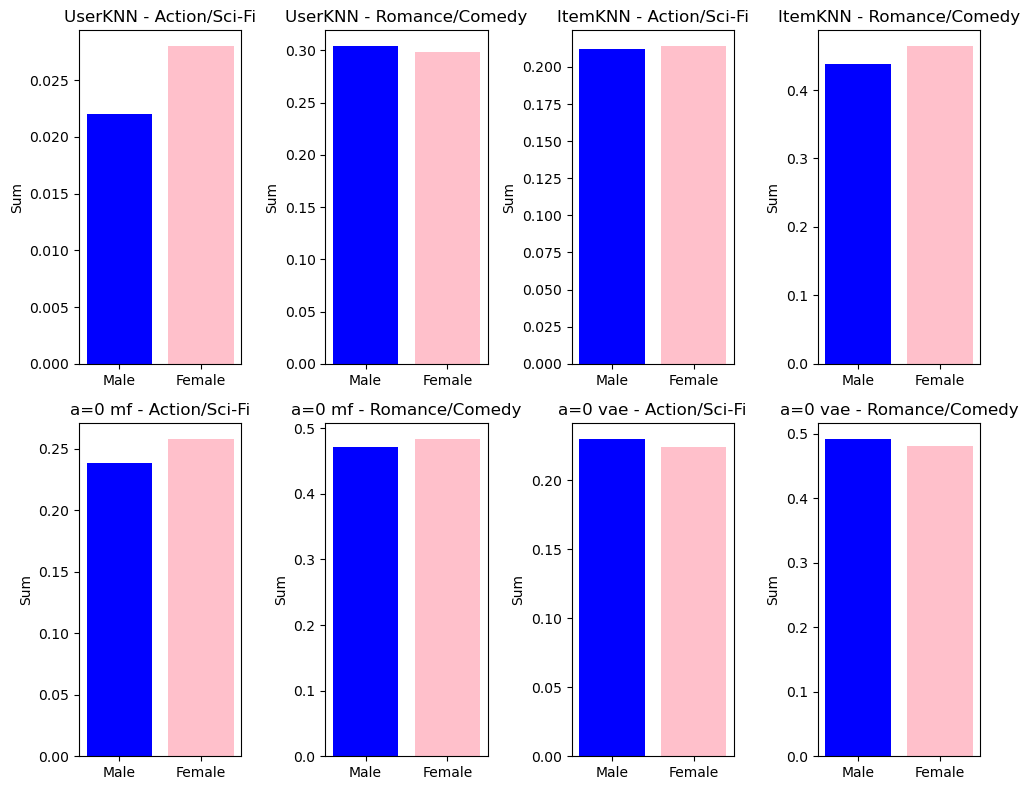

In [40]:
male_uids_new=[]
for i in male_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            # print(f"actual id {k} mapped {v}")
            male_uids_new.append(k)
female_uids_new=[]
for i in female_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            female_uids_new.append(k)
print(len(male_uids_new))
print(len(female_uids_new))
fig, ax = plt.subplots(2, 4, figsize=(10, 8)) 
ax = ax.flatten()
for i in range(len(models)):
    df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(reco_matrix_one_genre[i].shape[0]), top_k),
                "itemID": reco_matrix_one_genre[i].flatten(),
                "rank": np.tile(np.arange(1, top_k + 1), reco_matrix_one_genre[i].shape[0]),
            }
        )

    
    all_ids = male_uids_new+female_uids_new
    df_reco = df_reco[df_reco['userID'].isin(all_ids)]
   

    df_reco = pd.merge(df_reco, movies, on= "itemID", how="inner")
    # print(df_reco)
    
    df_reco_new = df_reco
    # df_reco_new = df_reco_new.groupby
    
    df_reco = df_reco.groupby("userID")[unique_genres].mean()
    # x_df = df_reco[unique_genres]
    
    df_reco = pd.merge(df_reco, users, on= "userID", how="inner")
    # print(df_reco)
    # x_df = pd.merge(x_df, users, on= "userID", how="inner")
    # print(x_df)
    df_reco = df_reco.groupby("Gender")[unique_genres].mean()
    

    # df_reco = df_reco.groupby("Gender")[unique_genres].sum()
    # print("::::::::")
    # print(df_reco[["Action","Romance"]])
    # # print(df_reco)
    # print(models[i].name)
    # print("::::::::")
    
    #  df_reco = df_reco.groupby("Gender")[unique_genres].sum()
    
    
    
    
    
    
    print("::::::::"*5)
    print(models[i].name)
    
    print(f"Action/SciFi male: {df_reco.loc[0, 'Sci-Fi'] + df_reco.loc[0, 'Action']:.4f}")
    print(f"Action/SciFi female: {df_reco.loc[1, 'Sci-Fi'] + df_reco.loc[1, 'Action']:.4f}")

    print("_"*30)
    print(f"RomanceDrama male: {df_reco.loc[0, 'Comedy'] + df_reco.loc[0, 'Romance']:.4f}")
    print(f"RomanceDrama female: {df_reco.loc[1, 'Comedy'] + df_reco.loc[1, 'Romance']:.4f}")

    print("::::::::"*5)
    
   
    action_scifi_male = df_reco.loc[0, 'Sci-Fi'] + df_reco.loc[0, 'Action'] 
    action_scifi_female = df_reco.loc[1, 'Sci-Fi'] + df_reco.loc[1, 'Action'] 
    
    romance_drama_male = df_reco.loc[0, 'Romance'] +  df_reco.loc[0, 'Comedy']
    romance_drama_female = df_reco.loc[1, 'Romance']+  df_reco.loc[1, 'Comedy']
    
    ax[2*i].bar(['Male', 'Female'], [action_scifi_male, action_scifi_female], color=['blue', 'pink'])
    ax[2*i].set_title(f"{models[i].name} - Action/Sci-Fi")
    ax[2*i].set_ylabel('Sum')
    ax[2*i + 1].bar(['Male', 'Female'], [romance_drama_male, romance_drama_female], color=['blue', 'pink'])
    ax[2*i + 1].set_title(f"{models[i].name} - Romance/Comedy")
    ax[2*i + 1].set_ylabel('Sum')
    
    
    
  
plt.tight_layout()
plt.show()   


# filtered_df = movies[movies['genres'].str.count('\|') == 1]
# top_k = 3
# 


50
50
__________
13.663967611336032
13.87557603686636
_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama
2.0
2.0
__________
__________
8.874125874125873
8.194352159468439
_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama
5.539166666666667
5.591836734693878
__________
__________
10.699381078691424
10.66531440162272
_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama_romancedrama
6.5851162790697675
6.524967433782024
__________
__________


KeyError: 0

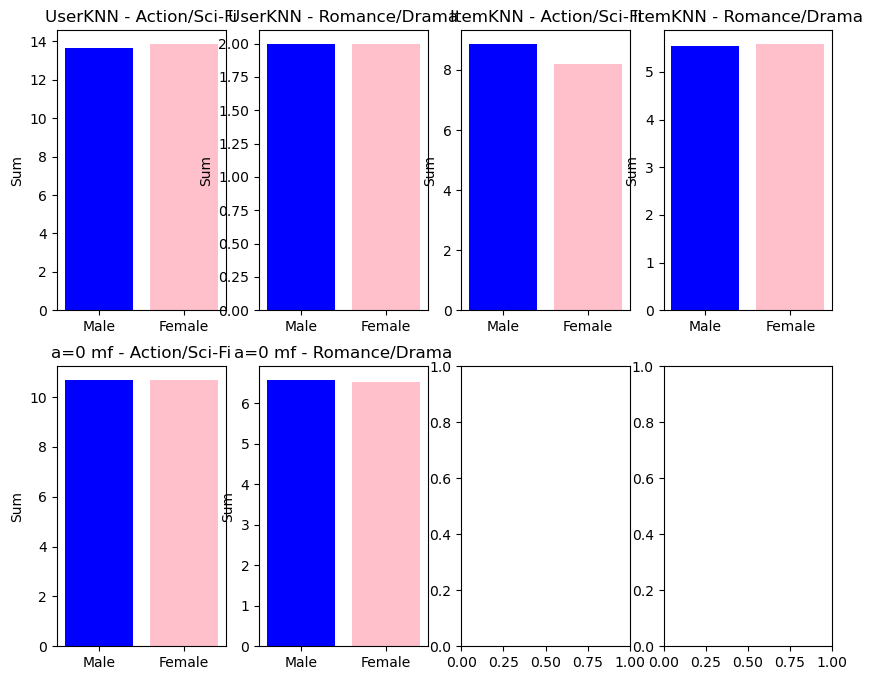

In [34]:
male_uids_new=[]
for i in male_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            # print(f"actual id {k} mapped {v}")
            male_uids_new.append(k)
female_uids_new=[]
for i in female_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            female_uids_new.append(k)
print(len(male_uids_new))
print(len(female_uids_new))
fig, ax = plt.subplots(2, 4, figsize=(10, 8)) 
ax = ax.flatten()
for i in range(len(models)):
    df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(reco_matrix_one_genre[i].shape[0]), top_k),
                "itemID": reco_matrix_one_genre[i].flatten(),
                "rank": np.tile(np.arange(1, top_k + 1), reco_matrix_one_genre[i].shape[0]),
            }
        )

    
    all_ids = male_uids_new+female_uids_new
    df_reco = df_reco[df_reco['userID'].isin(all_ids)]
   

    df_reco = pd.merge(df_reco, movies, on= "itemID", how="inner")
    acton= df_reco[df_reco['Action']==1]
    first_aciton_rank = acton.groupby('userID')['rank'].min().reset_index()
    act_df = pd.merge(first_aciton_rank, users, on= "userID", how="inner")
    avg_act_rank = act_df.groupby("Gender")["rank"].mean()
    
    sf= df_reco[df_reco['Sci-Fi']==1]
    first_scifi_rank = sf.groupby('userID')['rank'].min().reset_index()
    scifi_df = pd.merge(first_scifi_rank, users, on= "userID", how="inner")
    avg_sf_rank = scifi_df.groupby("Gender")["rank"].mean()
    
    crme= df_reco[df_reco['Crime']==1]
    first_crime_rank = crme.groupby('userID')['rank'].min().reset_index()
    crime_df = pd.merge(first_crime_rank, users, on= "userID", how="inner")
    avg_crime_rank = crime_df.groupby("Gender")["rank"].mean()
    
    
    
    
    # print(first_aciton_rank)
    
    rom= df_reco[df_reco['Romance']==1]
    first_rom_rank = rom.groupby('userID')['rank'].min().reset_index()
    rom_df = pd.merge(first_rom_rank, users, on= "userID", how="inner")
    avg_rom_rank = rom_df.groupby("Gender")["rank"].mean()
    
    drame= df_reco[df_reco['Drama']==1]
    first_drama_rank = drame.groupby('userID')['rank'].min().reset_index()
    drama_df = pd.merge(first_drama_rank, users, on= "userID", how="inner")
    avg_drama_rank = drama_df.groupby("Gender")["rank"].mean()
    
    com= df_reco[df_reco['Comedy']==1]
    first_comedy_rank = com.groupby('userID')['rank'].min().reset_index()
    comedy_df = pd.merge(first_comedy_rank, users, on= "userID", how="inner")
    avg_comedy_rank = comedy_df.groupby("Gender")["rank"].mean()
    
    print("_"*10)
    print(avg_sf_rank.loc[0]+avg_act_rank.loc[0])
    print(avg_sf_rank.loc[1]+avg_act_rank.loc[1] )
    print("_romancedrama"*10)
    
    print(avg_drama_rank.loc[0]+avg_rom_rank.loc[0])
    # print(avg_rom_rank.loc[0])
    print(avg_drama_rank.loc[1]+avg_rom_rank.loc[1])
    # print(avg_rom_rank.loc[1])
    print("_"*10)
    


    
    df_reco = pd.merge(df_reco, users, on= "userID", how="inner")
    df_reco = df_reco.groupby("Gender")[unique_genres].mean()

   
    action_scifi_male = avg_sf_rank.loc[0] + avg_act_rank.loc[0]
    action_scifi_female = avg_sf_rank.loc[1] + avg_act_rank.loc[1]
    
    romance_drama_male = avg_drama_rank.loc[0] + avg_rom_rank.loc[0]
    romance_drama_female = avg_drama_rank.loc[1] + avg_rom_rank.loc[1]
    
    ax[2*i].bar(['Male', 'Female'], [action_scifi_male, action_scifi_female], color=['blue', 'pink'])
    ax[2*i].set_title(f"{models[i].name} - Action/Sci-Fi")
    ax[2*i].set_ylabel('Sum')
    ax[2*i + 1].bar(['Male', 'Female'], [romance_drama_male, romance_drama_female], color=['blue', 'pink'])
    ax[2*i + 1].set_title(f"{models[i].name} - Romance/Drama")
    ax[2*i + 1].set_ylabel('Sum')
    
    
    
  
plt.tight_layout()
plt.show()   



In [205]:
df_reco.loc[0,"Action"]

0.42246642246642246

In [23]:
df_reco

,userID,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,Film-Noir,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama,Gender
0,1,4,3,4,0,1,0,0,0,0,2,2,3,1,1,0,3,1,4,1
1,5,4,3,3,0,0,0,0,0,0,1,3,4,1,1,0,3,0,4,0
2,6,4,3,4,0,1,0,0,0,0,2,2,3,1,1,0,3,1,4,0
3,7,4,3,4,0,1,0,0,0,0,2,2,3,1,1,0,3,1,4,1
4,8,7,5,2,0,1,0,1,0,0,1,3,7,1,1,0,3,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,937,5,2,4,0,0,0,0,0,0,1,4,6,0,1,0,4,0,5,0
542,938,4,3,4,0,1,0,0,0,0,2,2,3,1,1,0,3,1,4,1
543,939,4,3,3,0,0,0,0,0,0,1,3,4,1,1,0,3,0,4,0
544,940,4,3,4,0,1,0,0,0,0,2,2,3,1,1,0,3,1,4,1


In [24]:
print(len([2, 6, 15, 23, 26, 27, 42, 45, 50, 64, 65, 66, 73, 74, 76, 78, 80, 82, 86, 91, 96, 103, 105, 109, 113, 117, 123, 127, 128, 133, 135, 136, 138, 146, 148, 150, 151, 156, 158, 161, 166, 179, 195, 199, 211, 217, 219, 227, 228, 230, 231, 234, 242, 243, 245, 248, 254, 257, 258, 259, 262, 264, 265, 270, 277, 282, 287, 292, 301, 303, 304, 307, 308, 310, 311, 312, 318, 322, 323, 324, 325, 328, 329, 330, 334, 335, 336, 338, 341, 346, 351, 354, 359, 360, 362, 365, 369, 374, 377, 381, 383, 387, 389, 397, 398, 400, 401, 402, 403, 405, 410, 419, 420, 421, 427, 432, 440, 444, 449, 453, 464, 465, 467, 468, 470, 476, 479, 481, 482, 488, 491, 492, 494, 495, 496, 502, 512, 513, 514, 515, 516, 521, 522, 525, 528, 529, 531, 533, 536, 537, 543, 544, 546, 553, 560, 561, 562, 563, 564, 568, 571, 577, 586, 589, 592, 594, 595, 597, 602, 612, 618, 619, 620, 621, 622, 626, 627, 631, 632, 644, 645, 648, 649, 651, 655, 660, 664, 665, 668, 674, 676, 677, 680, 682, 683, 691, 692, 693, 694, 695, 696, 700, 701, 703, 716, 717, 720, 722, 725, 727, 728, 731, 739, 740, 742, 753, 759, 765, 767, 768, 770, 771, 772, 779, 782, 787, 789, 791, 793, 794, 800, 803, 808, 809, 812, 817, 819, 831, 832, 835, 837, 839, 843, 845, 846, 848, 850, 851, 856, 858, 869, 871, 875, 880, 882, 884, 893, 895, 896, 897, 900, 903, 905, 911, 916, 917, 924, 925, 927, 928, 929, 930, 937]
))

273


In [463]:
males = [0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 67, 68, 69, 70, 71, 72, 75, 77, 79, 81, 83, 84, 85, 87, 88, 89, 90, 92, 93, 94, 95, 97, 98, 99, 100, 101, 102, 104, 106, 107, 108, 110, 111, 112, 114, 115, 116, 118, 119, 120, 121, 122, 124, 125, 126, 129, 130, 131, 132, 134, 137, 139, 140, 141, 142, 143, 144, 145, 147, 149, 152, 153, 154, 155, 157, 159, 160, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 196, 197, 198, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 212, 213, 214, 215, 216, 218, 220, 221, 222, 223, 224, 225, 226, 229, 232, 233, 235, 236, 237, 238, 239, 240, 241, 244, 246, 247, 249, 250, 251, 252, 253, 255, 256, 260, 261, 263, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 278, 279, 280, 281, 283, 284, 285, 286, 288, 289, 290, 291, 293, 294, 295, 296, 297, 298, 299, 300, 302, 305, 306, 309, 313, 314, 315, 316, 317, 319, 320, 321, 326, 327, 331, 332, 333, 337, 339, 340, 342, 343, 344, 345, 347, 348, 349, 350, 352, 353, 355, 356, 357, 358, 361, 363, 364, 366, 367, 368, 370, 371, 372, 373, 375, 376, 378, 379, 380, 382, 384, 385, 386, 388, 390, 391, 392, 393, 394, 395, 396, 399, 404, 406, 407, 408, 409, 411, 412, 413, 414, 415, 416, 417, 418, 422, 423, 424, 425, 426, 428, 429, 430, 431, 433, 434, 435, 436, 437, 438, 439, 441, 442, 443, 445, 446, 447, 448, 450, 451, 452, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 466, 469, 471, 472, 473, 474, 475, 477, 478, 480, 483, 484, 485, 486, 487, 489, 490, 493, 497, 498, 499, 500, 501, 503, 504, 505, 506, 507, 508, 509, 510, 511, 517, 518, 519, 520, 523, 524, 526, 527, 530, 532, 534, 535, 538, 539, 540, 541, 542, 545, 547, 548, 549, 550, 551, 552, 554, 555, 556, 557, 558, 559, 565, 566, 567, 569, 570, 572, 573, 574, 575, 576, 578, 579, 580, 581, 582, 583, 584, 585, 587, 588, 590, 591, 593, 596, 598, 599, 600, 601, 603, 604, 605, 606, 607, 608, 609, 610, 611, 613, 614, 615, 616, 617, 623, 624, 625, 628, 629, 630, 633, 634, 635, 636, 637, 638, 639, 640, 641, 642, 643, 646, 647, 650, 652, 653, 654, 656, 657, 658, 659, 661, 662, 663, 666, 667, 669, 670, 671, 672, 673, 675, 678, 679, 681, 684, 685, 686, 687, 688, 689, 690, 697, 698, 699, 702, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 718, 719, 721, 723, 724, 726, 729, 730, 732, 733, 734, 735, 736, 737, 738, 741, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 754, 755, 756, 757, 758, 760, 761, 762, 763, 764, 766, 769, 773, 774, 775, 776, 777, 778, 780, 781, 783, 784, 785, 786, 788, 790, 792, 795, 796, 797, 798, 799, 801, 802, 804, 805, 806, 807, 810, 811, 813, 814, 815, 816, 818, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 833, 834, 836, 838, 840, 841, 842, 844, 847, 849, 852, 853, 854, 855, 857, 859, 860, 861, 862, 863, 864, 865, 866, 867, 868, 870, 872, 873, 874, 876, 877, 878, 879, 881, 883, 885, 886, 887, 888, 889, 890, 891, 892, 894, 898, 899, 901, 902, 904, 906, 907, 908, 909, 910, 912, 913, 914, 915, 918, 919, 920, 921, 922, 923, 926, 931, 932, 933, 934, 935, 936, 938, 939, 940, 941, 942]
len(males)

670

In [26]:
import numpy as np
np.random.seed(123)
selected_items_males = np.random.choice(males, 273, replace=False)
selected_items_males


array([232, 762,  57, 935, 926,  69, 361, 379, 733, 372,  52, 503, 888,
        13, 891, 599,  59, 411, 734, 429, 208, 104, 736, 273, 343, 534,
       140, 511, 557, 885, 679, 180, 352,  99, 828,  16, 623, 431, 189,
       408, 605, 769, 750, 932, 474, 210, 157, 548, 116, 409, 633, 108,
       746, 766, 865, 783, 218, 558, 729, 798, 100, 274, 873, 203, 392,
       931, 252, 295, 469, 542, 713, 604, 466, 251, 198, 288, 659, 666,
       298, 504,  63, 233,  71, 636, 625, 175, 712, 662, 744, 237,   7,
       418, 370, 938, 193, 721, 738, 263, 214, 173, 786, 841, 615, 606,
       455, 371,  41, 172,  37, 414, 652, 192, 675, 840, 797, 635, 863,
       855,  11, 689, 206, 907, 614, 667, 159, 247, 637, 754, 764, 578,
       425, 590, 309, 337,  48, 131, 921, 240, 524,  84, 423, 224, 477,
        95, 363, 826, 776, 130, 215, 260, 266, 160, 450, 283,  28, 294,
       187, 366, 805, 629, 373, 333, 184, 551,  43, 711, 868, 200,  49,
       608, 327, 795, 497,  79,  40,  39, 350, 790, 820, 155,  1

In [465]:
x=[0, 1, 4, 8, 10, 12, 14, 16, 17, 19, 25, 28, 30, 32, 35, 37, 38, 39, 44, 47, 49, 51, 52, 53, 54, 56, 62, 70, 75, 77, 79, 81, 83, 87, 88, 89, 90, 95, 101, 102, 107, 114, 115, 118, 120, 125, 126, 129, 131, 134, 143, 144, 149, 152, 155, 162, 164, 170, 172, 176, 178, 180, 181, 187, 189, 191, 201, 205, 206, 207, 208, 210, 212, 215, 221, 222, 232, 235, 236, 237, 240, 247, 249, 251, 253, 263, 266, 275, 276, 280, 285, 297, 305, 306, 314, 316, 331, 332, 339, 340, 342, 345, 348, 349, 353, 355, 356, 361, 363, 367, 368, 370, 371, 372, 376, 378, 384, 385, 388, 392, 394, 399, 404, 408, 409, 418, 425, 426, 428, 438, 439, 442, 448, 460, 461, 462, 466, 469, 473, 477, 480, 485, 486, 490, 498, 500, 507, 508, 510, 518, 524, 527, 532, 534, 535, 538, 547, 548, 549, 550, 551, 554, 556, 558, 559, 565, 566, 574, 575, 576, 579, 587, 588, 590, 596, 598, 604, 609, 611, 613, 614, 616, 630, 634, 635, 636, 638, 639, 640, 642, 646, 650, 656, 657, 662, 663, 667, 669, 672, 681, 684, 689, 690, 698, 699, 710, 711, 715, 719, 726, 734, 737, 745, 748, 749, 755, 756, 757, 758, 761, 766, 769, 774, 775, 781, 783, 786, 796, 797, 799, 806, 807, 813, 821, 823, 824, 825, 828, 836, 838, 840, 844, 847, 849, 852, 853, 854, 855, 859, 860, 861, 863, 866, 881, 885, 890, 891, 892, 901, 908, 909, 910, 912, 914, 919, 920, 923, 933, 934, 936, 940, 942]
len(x)

272

In [472]:
256 in males

True

In [469]:
man

array([256])